# Análisis de Comorbilidades — Solapamiento Feature-Diagnóstico

| | |
|---|---|
| **Dataset** | `data/processed/processed_data.csv` — 875 registros |
| **Objetivo** | Verificar si las features BASC-3 se solapan con los criterios que definen TND, TEAZ y TEA |
| **Método** | Clasificadores binarios por comorbilidad + distribuciones + coeficiente de solapamiento (OVL) |

**Hipótesis a contrastar:**
- `atipicidad_basc3` funciona como proxy de la comorbilidad TEA/TEAZ
- `agresividad_basc3` + `problemas_conducta_basc3` funcionan como proxy de TND

Este análisis complementa los hallazgos del EDA bivariado (`eda_bivariate.ipynb`, Bloque 2) que señaló que esas escalas BASC-3 estaban "más relacionadas con comorbilidades conductuales que con el subtipo TDAH per se".

### Tabla de contenidos
1. Configuración y datos
2. Importancia binaria por comorbilidad (clasificadores OvR aislados)
3. Distribuciones: comparación directa por comorbilidad
4. Coeficiente de solapamiento (OVL)
5. Síntesis y conclusión metodológica

---
> **Conexión con otros notebooks:** los modelos RF de referencia están en `model_13clases.ipynb`. El impacto en rendimiento al eliminar features sospechosas está en `ablation_study.ipynb`.

---
## Bloque 1 — Configuración y datos

In [8]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'grid.alpha': 0.35,
})
C_BLUE='#4C72B0'; C_ORG='#DD8452'; C_GRN='#55A868'
C_RED='#C44E52';  C_GRAY='#8C8C8C'; C_PURP='#8172B2'

FEATURE_LABELS = {
    'problemas_atencion_basc3' : 'Prob. atención (BASC-3)',
    'hiperactividad_basc3'     : 'Hiperactividad (BASC-3)',
    'problemas_conducta_basc3' : 'Prob. conducta (BASC-3)',
    'agresividad_basc3'        : 'Agresividad (BASC-3)',
    'atipicidad_basc3'         : 'Atipicidad (BASC-3)',
    'cit'                      : 'CIT',
    'fluidez_fonologica'       : 'Fluidez fonológica',
    'antecedentes_familiares'  : 'Antec. familiares',
    'retrasos_desarrollo'      : 'Retrasos desarrollo',
    'antecedentes_obstetricos' : 'Antec. obstétricos',
    'edad':'Edad', 'escolaridad':'Escolaridad',
    'sexo':'Sexo', 'lateralidad':'Lateralidad',
}
BASC_FEATS = ['agresividad_basc3','hiperactividad_basc3','problemas_conducta_basc3',
              'problemas_atencion_basc3','atipicidad_basc3']
print('Setup OK.')


Setup OK.


In [9]:
df = pd.read_csv('../data/processed/processed_data.csv', encoding='utf-8-sig')
print(f"Dataset: {df.shape[0]} × {df.shape[1]}")

FEATURES = ['edad','sexo','escolaridad','lateralidad',
            'antecedentes_familiares','antecedentes_obstetricos','retrasos_desarrollo',
            'cit','agresividad_basc3','hiperactividad_basc3',
            'problemas_conducta_basc3','problemas_atencion_basc3',
            'atipicidad_basc3','fluidez_fonologica']
FEATURES_CAT = ['sexo','lateralidad','antecedentes_familiares',
                'antecedentes_obstetricos','retrasos_desarrollo']

X_raw = df[FEATURES].copy()
enc   = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_raw[FEATURES_CAT] = enc.fit_transform(X_raw[FEATURES_CAT])

# ── Etiquetas y flags de comorbilidad ──────────────────────────────────────
le13 = LabelEncoder()
y13  = le13.fit_transform(df['etiqueta'])
labels13 = le13.classes_

df['_lbl'] = df['etiqueta'].str.lower()
df['has_tnd']  = df['_lbl'].str.contains('tnd')
df['has_tea']  = df['_lbl'].str.contains(r'\btea\b')
df['has_teaz'] = df['_lbl'].str.contains('teaz')
df['has_any_comorbidity'] = df['has_tnd'] | df['has_tea'] | df['has_teaz']
df['is_tdah']  = ~df['_lbl'].str.contains('típico')

print(f"\nDistribución de comorbilidades en la muestra TDAH:")
tdah = df[df['is_tdah']]
print(f"  Con TND  : {df['has_tnd'].sum()} ({df['has_tnd'].mean()*100:.1f}%)")
print(f"  Con TEAZ : {df['has_teaz'].sum()} ({df['has_teaz'].mean()*100:.1f}%)")
print(f"  Con TEA  : {df['has_tea'].sum()} ({df['has_tea'].mean()*100:.1f}%)")
print(f"  Sin comorbilidad: {(~df['has_any_comorbidity'] & df['is_tdah']).sum()}")


Dataset: 875 × 18

Distribución de comorbilidades en la muestra TDAH:
  Con TND  : 196 (22.4%)
  Con TEAZ : 233 (26.6%)
  Con TEA  : 102 (11.7%)
  Sin comorbilidad: 232


📋 Los flags de comorbilidad se derivan de la cadena de texto de `etiqueta`. Un caso tiene `has_tnd=True` si su etiqueta contiene 'tnd', y análogo para TEA y TEAZ. Un caso puede tener a lo sumo una comorbilidad (la muestra no registra co-ocurrencia múltiple de comorbilidades en las 13 etiquetas).

---
## Bloque 2 — Importancia de features para distinguir cada comorbilidad

**Hipótesis a contrastar** (derivada del diagnóstico metodológico y del EDA bivariado):
- `atipicidad_basc3` domina la distinción **TEA / TEAZ** vs. mismo subtipo sin comorbilidad
- `agresividad_basc3` + `problemas_conducta_basc3` dominan la distinción **TND** vs. mismo subtipo sin comorbilidad

**Metodología:** para cada tipo de comorbilidad se entrena un clasificador binario (tiene/no tiene la comorbilidad) usando **solo los casos del mismo subtipo TDAH principal**. Esto aísla el efecto de la comorbilidad del efecto del subtipo base.

Si la hipótesis es correcta, la importancia de las features sospechosas será desproporcionadamente alta en el clasificador binario de su comorbilidad correspondiente.

---
### 2.1 Clasificador binario para cada comorbilidad


  TND  (Trastorno Negativista Desafiante): 196 positivos, 567 negativos
  CV F1=0.936 ± 0.022  |  AUC=0.997 ± 0.002


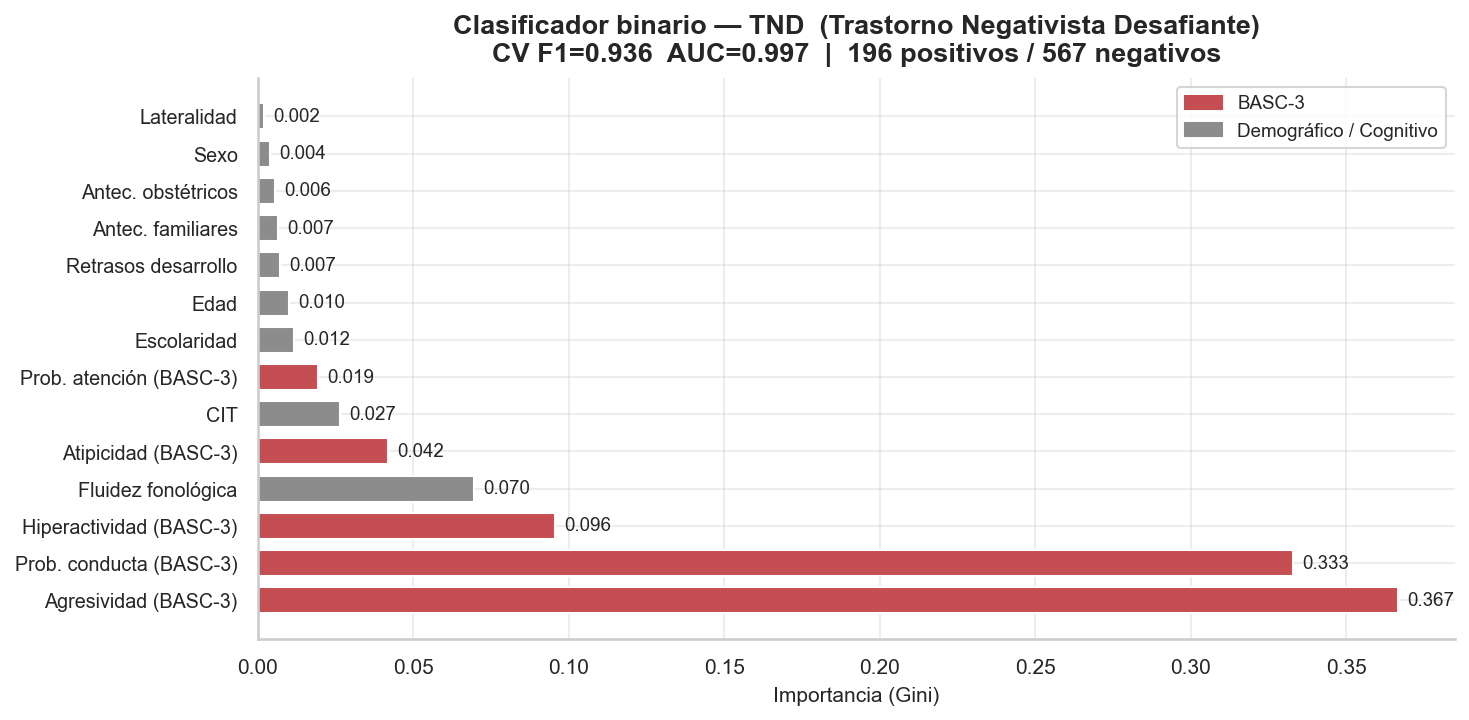

  Feature más importante: 'Agresividad (BASC-3)' → 0.367 (36.7% del total)
  Importancia acumulada BASC-3: 85.7%

  TEAZ (Espectro Autista subcrítico): 233 positivos, 530 negativos
  CV F1=0.952 ± 0.015  |  AUC=0.996 ± 0.003


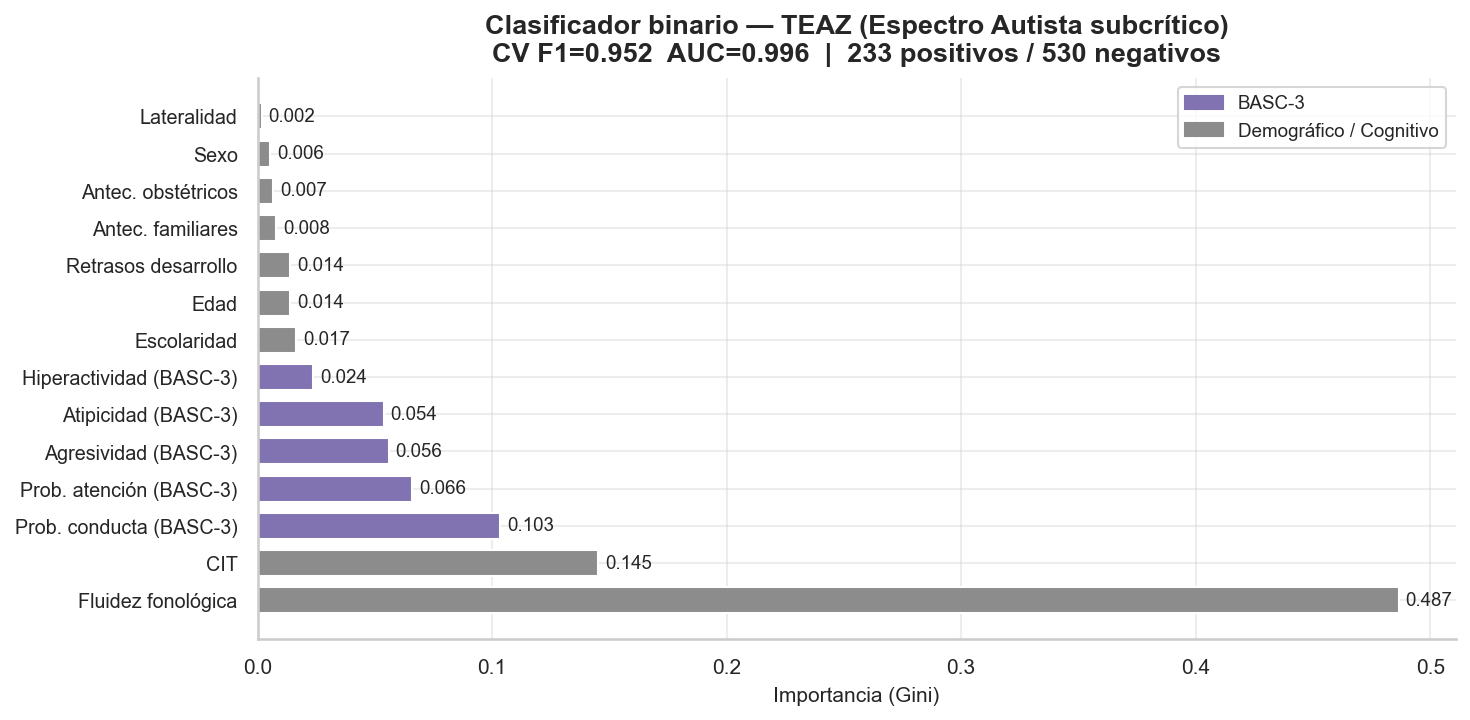

  Feature más importante: 'Fluidez fonológica' → 0.487 (48.7% del total)
  Importancia acumulada BASC-3: 30.3%

  TEA  (Trastorno del Espectro Autista): 102 positivos, 661 negativos
  CV F1=0.995 ± 0.010  |  AUC=1.000 ± 0.000


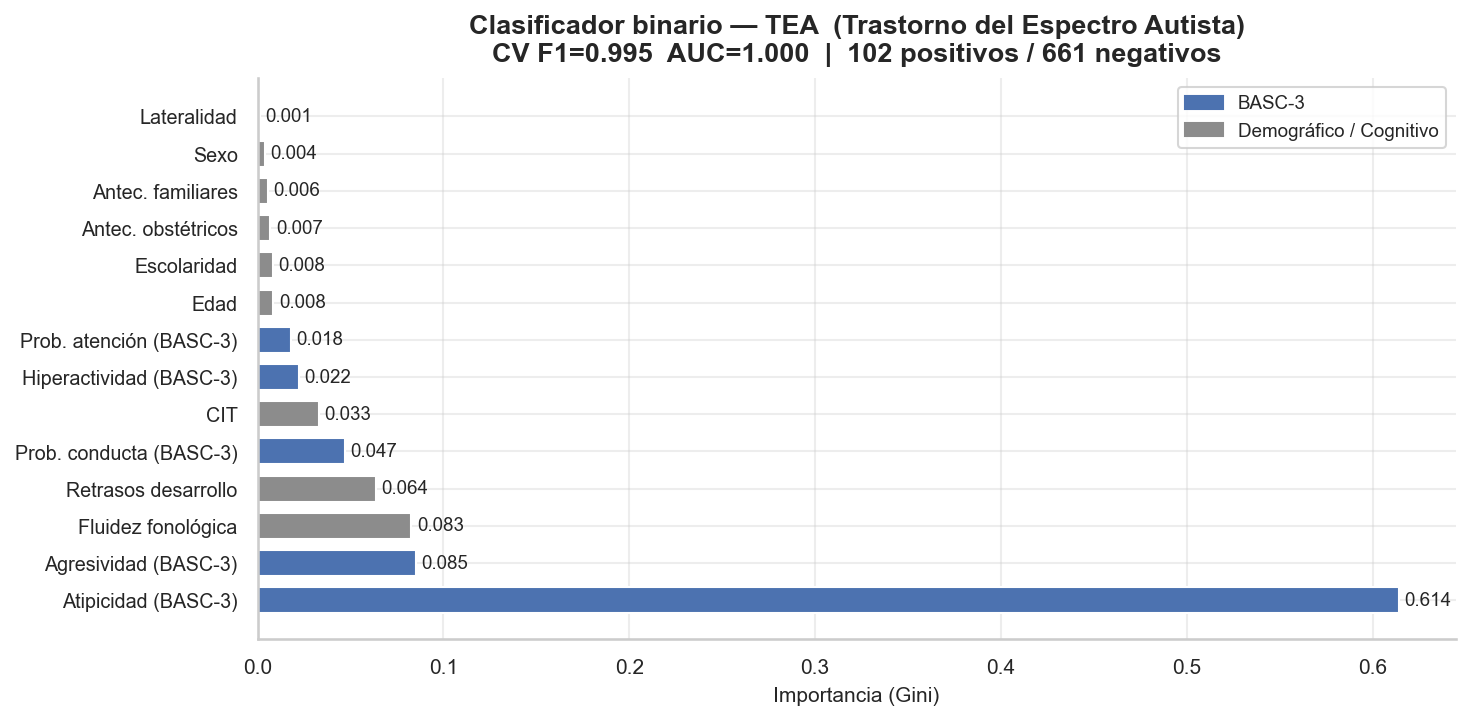

  Feature más importante: 'Atipicidad (BASC-3)' → 0.614 (61.4% del total)
  Importancia acumulada BASC-3: 78.6%


In [10]:
def binary_comorbidity_clf(flag_col, label, color, df, X_raw, features):
    mask = df['is_tdah'].values
    y_bin = df.loc[mask, flag_col].astype(int).values
    X_bin = X_raw[mask].copy()

    n_pos = y_bin.sum()
    n_neg = (y_bin == 0).sum()
    print(f"\n{'='*55}")
    print(f"  {label}: {n_pos} positivos, {n_neg} negativos")

    if n_pos < 10:
        print(f"  Insuficientes casos positivos para clasificación. Omitido.")
        return None

    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    res = cross_validate(rf, X_bin, y_bin, cv=cv,
                         scoring=['f1','roc_auc'], return_train_score=False)
    f1_m  = res['test_f1'].mean()
    auc_m = res['test_roc_auc'].mean()
    print(f"  CV F1={f1_m:.3f} ± {res['test_f1'].std():.3f}  |  AUC={auc_m:.3f} ± {res['test_roc_auc'].std():.3f}")

    # Feature importance en train completo
    rf.fit(X_bin, y_bin)
    imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    imp_labels = [FEATURE_LABELS.get(f,f) for f in imp.index]

    fig, ax = plt.subplots(figsize=(10, 5))
    bar_cols = [color if f in BASC_FEATS else C_GRAY for f in imp.index]
    bars = ax.barh(range(len(imp)), imp.values, color=bar_cols, edgecolor='white', height=0.7)
    for bar, val in zip(bars, imp.values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp_labels, fontsize=9.5)
    ax.set_xlabel('Importancia (Gini)', fontsize=10)
    ax.set_title(f'Clasificador binario — {label}\n'
                 f'CV F1={f1_m:.3f}  AUC={auc_m:.3f}  |  {n_pos} positivos / {n_neg} negativos', pad=8)
    p1 = mpatches.Patch(color=color, label='BASC-3')
    p2 = mpatches.Patch(color=C_GRAY, label='Demográfico / Cognitivo')
    ax.legend(handles=[p1,p2], fontsize=9)
    plt.tight_layout()
    plt.show()

    # ¿Qué % de la importancia total cae en la feature sospechosa?
    top1 = imp.index[0]
    top1_pct = imp.values[0] / imp.values.sum() * 100
    basc_pct  = imp[BASC_FEATS].sum() / imp.values.sum() * 100
    print(f"  Feature más importante: '{FEATURE_LABELS.get(top1,top1)}' → {imp.values[0]:.3f} ({top1_pct:.1f}% del total)")
    print(f"  Importancia acumulada BASC-3: {basc_pct:.1f}%")
    return imp

imp_tnd  = binary_comorbidity_clf('has_tnd',  'TND  (Trastorno Negativista Desafiante)',
                                    C_RED,  df, X_raw, FEATURES)
imp_teaz = binary_comorbidity_clf('has_teaz', 'TEAZ (Espectro Autista subcrítico)',
                                   C_PURP, df, X_raw, FEATURES)
imp_tea  = binary_comorbidity_clf('has_tea',  'TEA  (Trastorno del Espectro Autista)',
                                   C_BLUE, df, X_raw, FEATURES)


📋 **Interpretación — Importancia binaria por comorbilidad**

Los clasificadores binarios aíslan exactamente la pregunta metodológica: *dentro del mismo subtipo TDAH, ¿qué variable diferencia a los casos con comorbilidad de los que no la tienen?*

Interpretación esperada si la hipótesis de solapamiento es correcta:
- **TND**: `agresividad_basc3` y `problemas_conducta_basc3` concentran la importancia → el modelo detecta TND porque esas escalas BASC-3 miden directamente lo que el clínico evalúa para diagnosticar TND. La distinción es real pero no independiente del diagnóstico.
- **TEA/TEAZ**: `atipicidad_basc3` domina → análogo al caso TND, la escala fue diseñada para capturar síntomas del espectro autista.

Si la F1 del clasificador binario es baja (<0.60) a pesar del desequilibrio de clases corregido, indicaría que las features disponibles no son suficientes para distinguir la comorbilidad, y que el modelo de 13 clases puede estar aprendiendo ruido o dependencias espurias.

---
## Bloque 3 — Distribuciones por comorbilidad: señal vs. ruido

El EDA bivariado mostró que la escala `atipicidad_basc3` tiene la mayor varianza entre individuos (más outliers IQR) y que `agresividad_basc3` + `problemas_conducta_basc3` están "más relacionadas con comorbilidades conductuales (TND) que con el subtipo de TDAH per se" (eda_bivariate.ipynb, Bloque 2).

Este bloque cuantifica esas diferencias directamente, comparando las distribuciones dentro de cada subtipo principal entre casos con y sin comorbilidad.

---
### 3.1 Atipicidad BASC-3: TEA/TEAZ vs. mismo subtipo sin comorbilidad

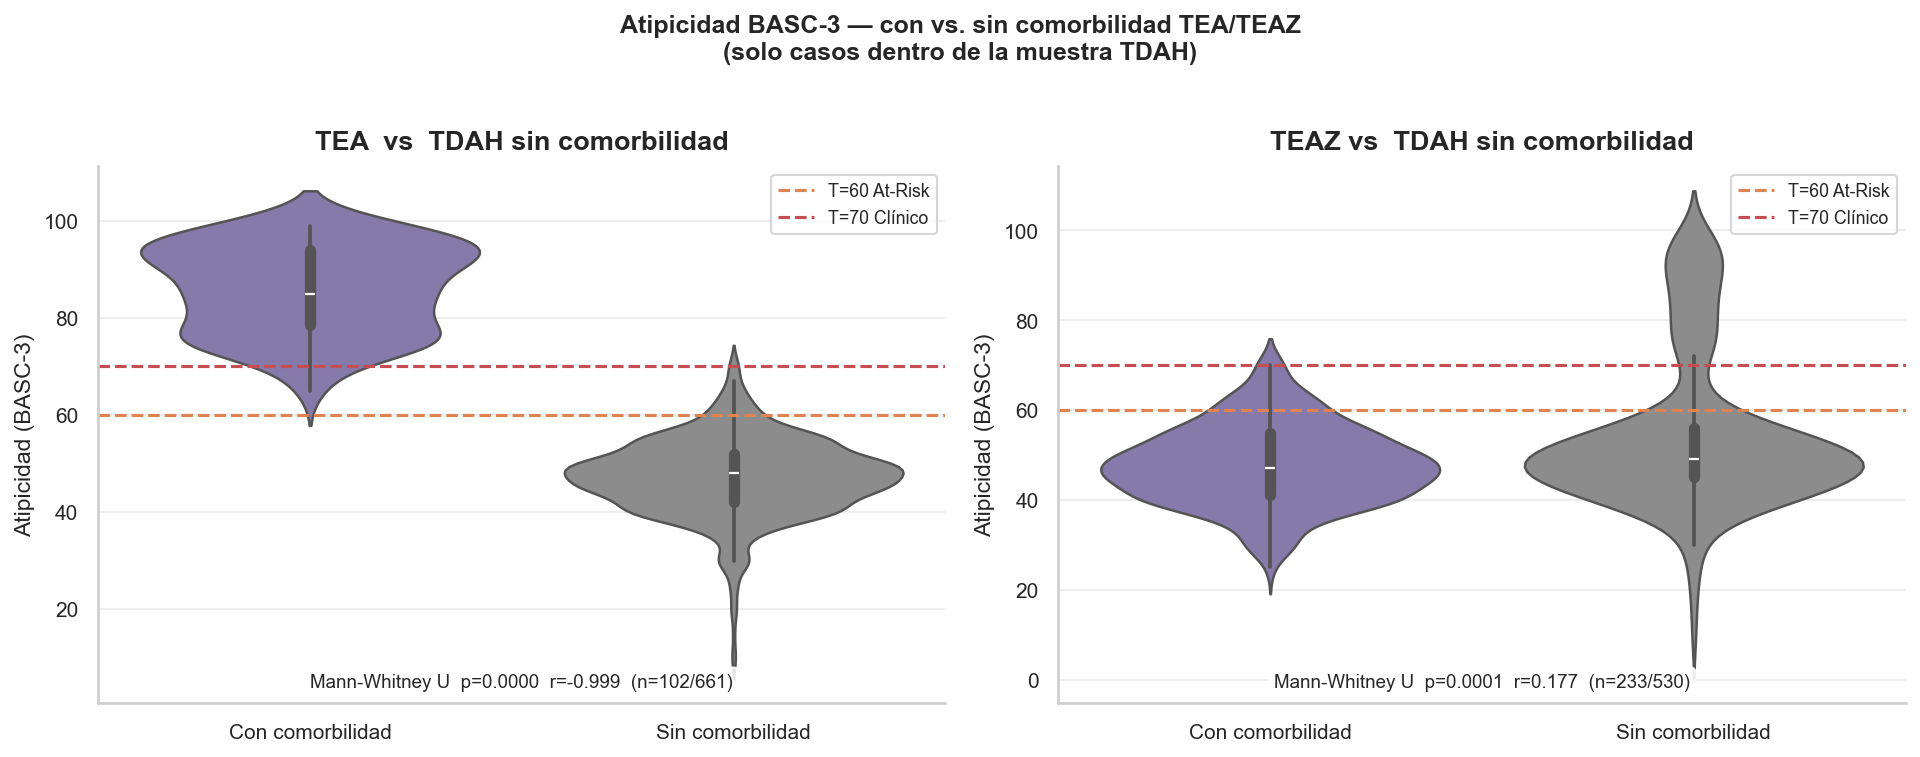

In [11]:
# ── Variables de interés y grupos ────────────────────────────────────────
def get_comorbidity_groups(df, flag_col):
    tdah_mask = df['is_tdah']
    pos = df[tdah_mask & df[flag_col]][BASC_FEATS + ['cit','fluidez_fonologica','etiqueta']].copy()
    neg = df[tdah_mask & ~df[flag_col]][BASC_FEATS + ['cit','fluidez_fonologica','etiqueta']].copy()
    return pos, neg

pos_tea, neg_tea   = get_comorbidity_groups(df, 'has_tea')
pos_teaz, neg_teaz = get_comorbidity_groups(df, 'has_teaz')
pos_tnd, neg_tnd   = get_comorbidity_groups(df, 'has_tnd')

# ── Plot: atipicidad para TEA/TEAZ vs sin comorbilidad ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (pos, neg, title) in zip(axes, [
    (pos_tea,  neg_tea,  'TEA  vs  TDAH sin comorbilidad'),
    (pos_teaz, neg_teaz, 'TEAZ vs  TDAH sin comorbilidad'),
]):
    data = pd.DataFrame({
        'Atipicidad (BASC-3)': pd.concat([pos['atipicidad_basc3'], neg['atipicidad_basc3']]),
        'Grupo': ['Con comorbilidad']*len(pos) + ['Sin comorbilidad']*len(neg)
    })
    sns.violinplot(data=data, x='Grupo', y='Atipicidad (BASC-3)',
                   palette=[C_PURP, C_GRAY], inner='box', ax=ax, linewidth=1.2)
    ax.axhline(60, color=C_ORG,  lw=1.5, linestyle='--', label='T=60 At-Risk')
    ax.axhline(70, color=C_RED,  lw=1.5, linestyle='--', label='T=70 Clínico')
    ax.set_title(title, pad=8)
    ax.legend(fontsize=8.5)

    # Mann-Whitney U
    stat, pval = stats.mannwhitneyu(pos['atipicidad_basc3'], neg['atipicidad_basc3'],
                                     alternative='two-sided')
    n1, n2 = len(pos), len(neg)
    r_rb = 1 - 2*stat/(n1*n2)   # rank-biserial correlation = effect size
    ax.set_xlabel('')
    ax.text(0.5, 0.03, f'Mann-Whitney U  p={pval:.4f}  r={r_rb:.3f}  (n={n1}/{n2})',
            ha='center', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

fig.suptitle('Atipicidad BASC-3 — con vs. sin comorbilidad TEA/TEAZ\n'
             '(solo casos dentro de la muestra TDAH)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


📋 **Interpretación — Atipicidad en TEA/TEAZ**

La comparación directa entre casos TEA/TEAZ y el resto de la muestra TDAH permite responder: ¿la escala de Atipicidad BASC-3 ya separa estos grupos *antes* de que el clínico asigne la etiqueta?

Interpretación del effect size (rank-biserial r):
- |r| < 0.20 → efecto pequeño: la Atipicidad por sí sola no discrimina la comorbilidad
- |r| 0.20–0.50 → efecto moderado: hay señal, pero con mucho solapamiento
- |r| > 0.50 → efecto grande: la distribución de Atipicidad ya separa sustancialmente los grupos

Si el effect size es grande y el p-valor < 0.05, la escala Atipicidad funciona como proxy de la comorbilidad TEA/TEAZ. Esto no invalida el modelo, pero sí implica que el modelo está aprovechando una feature que está parcialmente "construida" para capturar el mismo fenómeno que el diagnóstico mide.

---
### 3.2 Agresividad y Problemas de conducta: TND vs. mismo subtipo sin TND

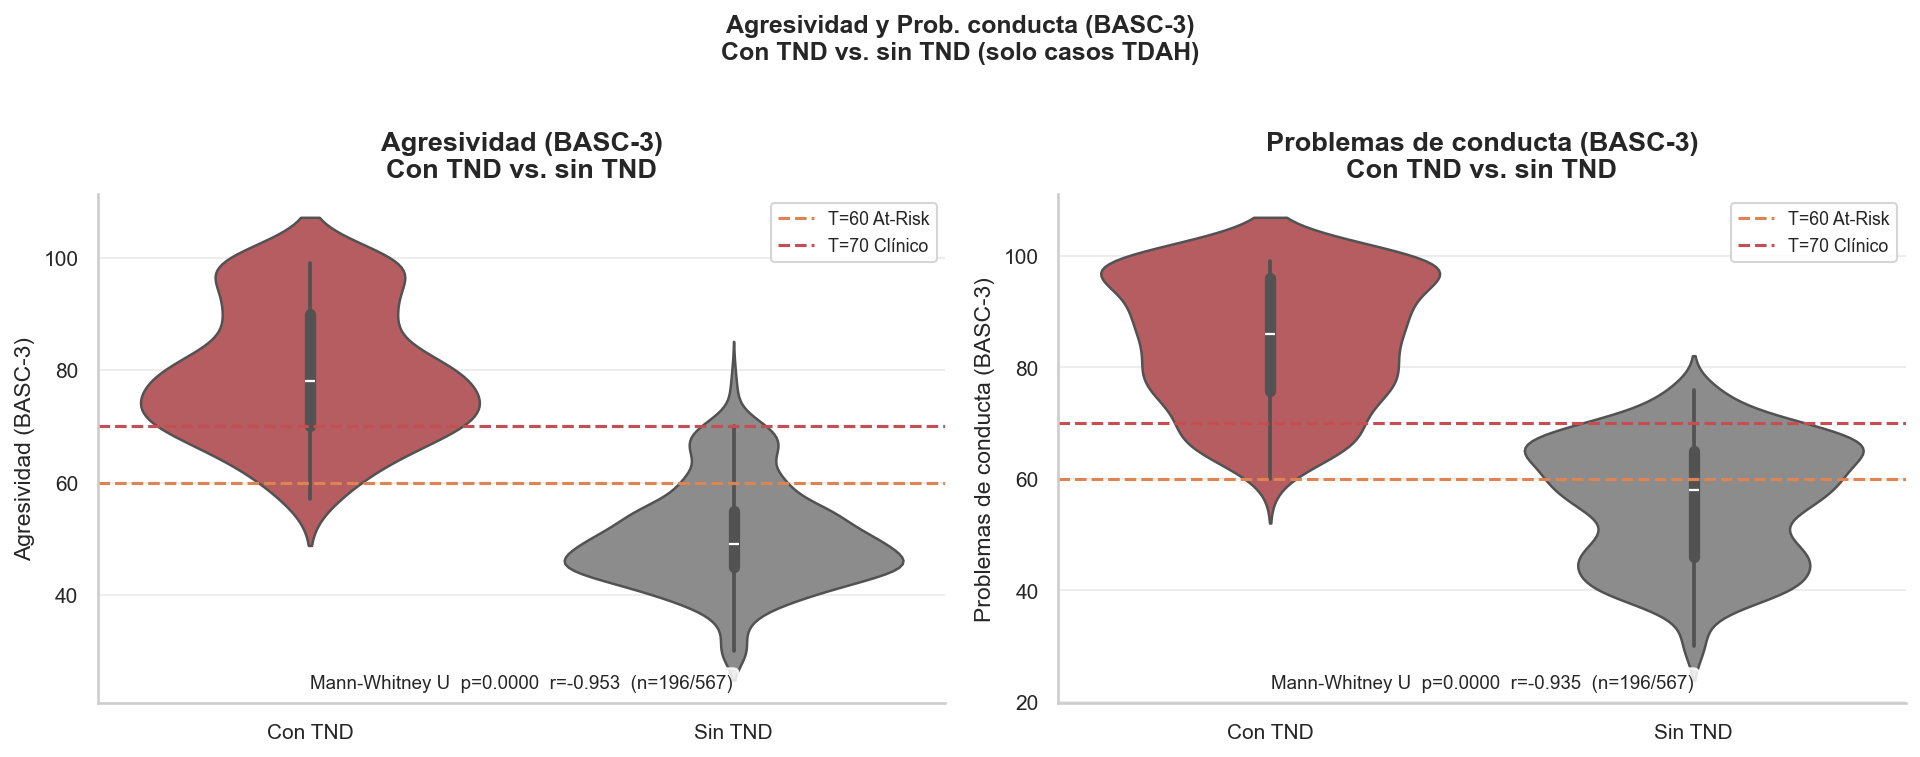

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vars_tnd = ['agresividad_basc3', 'problemas_conducta_basc3']
titles   = ['Agresividad (BASC-3)', 'Problemas de conducta (BASC-3)']

for ax, var, t in zip(axes, vars_tnd, titles):
    data = pd.DataFrame({
        t: pd.concat([pos_tnd[var], neg_tnd[var]]),
        'Grupo': ['Con TND']*len(pos_tnd) + ['Sin TND']*len(neg_tnd)
    })
    sns.violinplot(data=data, x='Grupo', y=t,
                   palette=[C_RED, C_GRAY], inner='box', ax=ax, linewidth=1.2)
    ax.axhline(60, color=C_ORG, lw=1.5, linestyle='--', label='T=60 At-Risk')
    ax.axhline(70, color=C_RED, lw=1.5, linestyle='--', label='T=70 Clínico')
    ax.set_title(f'{t}\nCon TND vs. sin TND', pad=8)
    ax.legend(fontsize=8.5)
    ax.set_xlabel('')

    stat, pval = stats.mannwhitneyu(pos_tnd[var], neg_tnd[var], alternative='two-sided')
    n1, n2 = len(pos_tnd), len(neg_tnd)
    r_rb = 1 - 2*stat/(n1*n2)
    ax.text(0.5, 0.03, f'Mann-Whitney U  p={pval:.4f}  r={r_rb:.3f}  (n={n1}/{n2})',
            ha='center', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

fig.suptitle('Agresividad y Prob. conducta (BASC-3)\n'
             'Con TND vs. sin TND (solo casos TDAH)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


📋 **Interpretación — Agresividad y Conducta en TND**

El TND (Trastorno Negativista Desafiante) se caracteriza clínicamente por conducta desafiante, agresiva y negativista. Las escalas BASC-3 de Agresividad y Problemas de conducta miden exactamente estos dominios. Si hay diferencias significativas y de gran tamaño de efecto, confirma que estas escalas son proxies de la dimensión TND en esta muestra.

Contexto del EDA bivariado: el notebook eda_bivariate.ipynb señala que "agresividad y prob. conducta están más relacionadas con comorbilidades conductuales (TND) que con el subtipo de TDAH per se". Este gráfico cuantifica exactamente ese hallazgo.

---
### 3.3 Visión global: z-scores por comorbilidad

Complementando el heatmap de z-scores del EDA bivariado, esta vista muestra el perfil clínico medio de cada tipo de comorbilidad comparado con los casos TDAH sin comorbilidad.

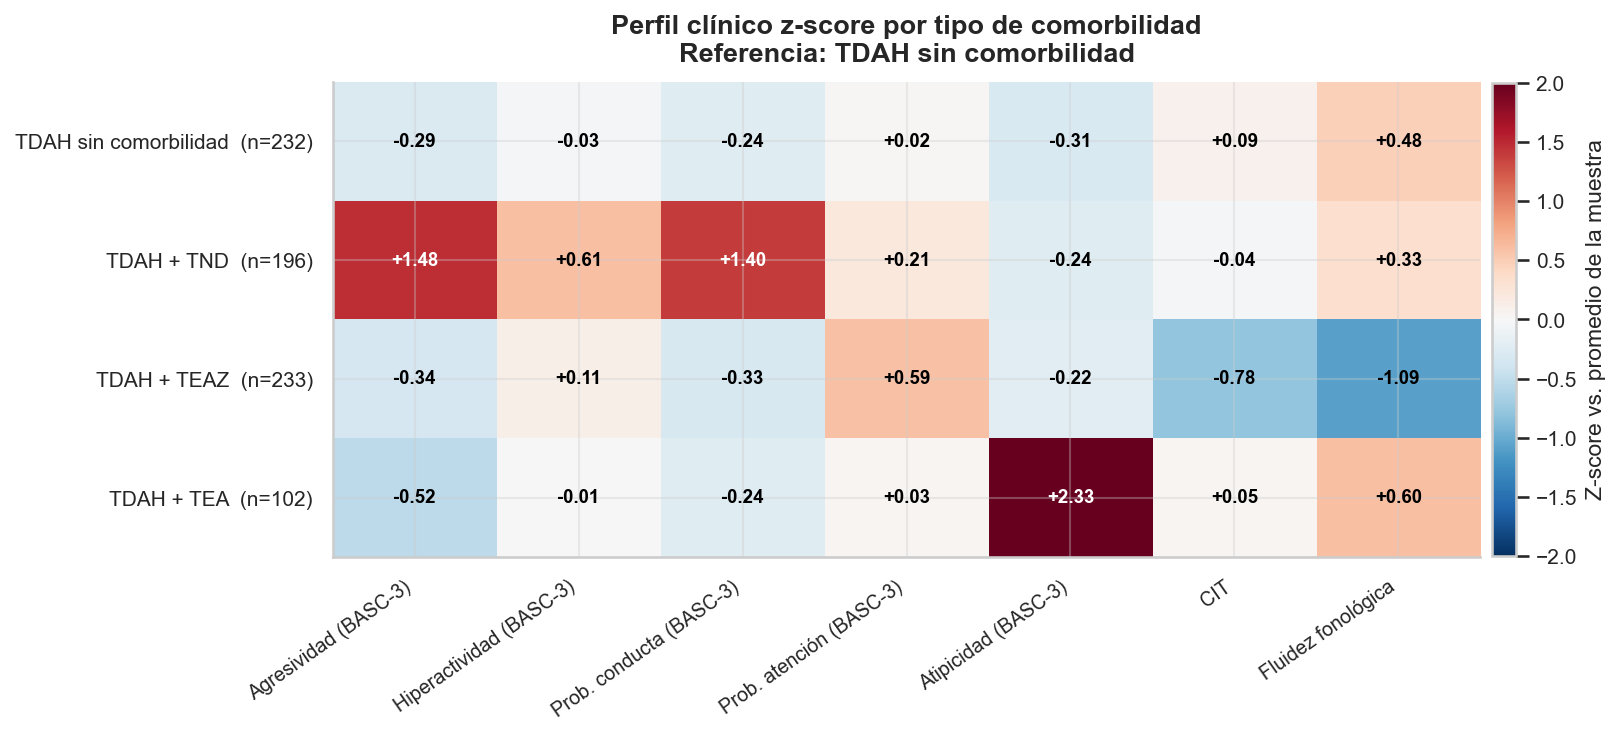

In [13]:
cont_feats = BASC_FEATS + ['cit','fluidez_fonologica']
cont_labels = [FEATURE_LABELS[f] for f in cont_feats]

groups = {
    'TDAH sin comorbilidad'  : df[df['is_tdah'] & ~df['has_any_comorbidity']],
    'TDAH + TND'             : df[df['has_tnd']],
    'TDAH + TEAZ'            : df[df['has_teaz']],
    'TDAH + TEA'             : df[df['has_tea']],
}

mu  = df[cont_feats].mean()
sig = df[cont_feats].std().replace(0, 1)

rows, row_labels = [], []
for lbl, grp in groups.items():
    if len(grp) == 0: continue
    z = (grp[cont_feats].mean() - mu) / sig
    rows.append(z.values)
    row_labels.append(f'{lbl}  (n={len(grp)})')

heat = pd.DataFrame(rows, columns=cont_labels, index=row_labels)

fig, ax = plt.subplots(figsize=(11, max(3.5, len(rows)*0.9 + 1.5)))
im = ax.imshow(heat.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(cont_labels)))
ax.set_xticklabels(cont_labels, rotation=35, ha='right', fontsize=9.5)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)
for i in range(len(rows)):
    for j in range(len(cont_feats)):
        v = heat.iloc[i,j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 1.3 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax, label='Z-score vs. promedio de la muestra', fraction=0.02, pad=0.01)
ax.set_title('Perfil clínico z-score por tipo de comorbilidad\n'
             'Referencia: TDAH sin comorbilidad', pad=10)
plt.tight_layout()
plt.show()


📋 **Interpretación — Heatmap z-score por comorbilidad**

Este heatmap responde directamente la pregunta metodológica: ¿los grupos de comorbilidad difieren principalmente en las variables BASC-3 que están conceptualmente relacionadas con su definición diagnóstica?

- **TDAH + TND** debería mostrar z-scores elevados en Agresividad y Prob. conducta respecto a TDAH sin comorbilidad
- **TDAH + TEA/TEAZ** debería mostrar z-scores elevados en Atipicidad
- **CIT y Fluidez fonológica** deberían mostrar z-scores más negativos en TEA/TEAZ que en TND (los perfiles cognitivos difieren)

Si el patrón es exactamente el esperado (columnas de atipicidad rojas para TEA, columnas de conducta/agresividad rojas para TND), confirma que las features disponibles capturan información que se solapa con la definición diagnóstica de las comorbilidades.

---
## Bloque 4 — Cuantificación del solapamiento: ¿hay separabilidad real?

Más allá de si las diferencias son estadísticamente significativas, lo que importa para el modelo es si las distribuciones son **suficientemente separadas** como para clasificar correctamente. Dos distribuciones pueden ser significativamente diferentes (p < 0.01) pero solaparse tanto que un clasificador no pueda distinguirlas.

Se calcula el **Coeficiente de Solapamiento (OVL)**: proporción del área que comparten las dos distribuciones. OVL = 1.0 → solapamiento total; OVL = 0.0 → separación perfecta.

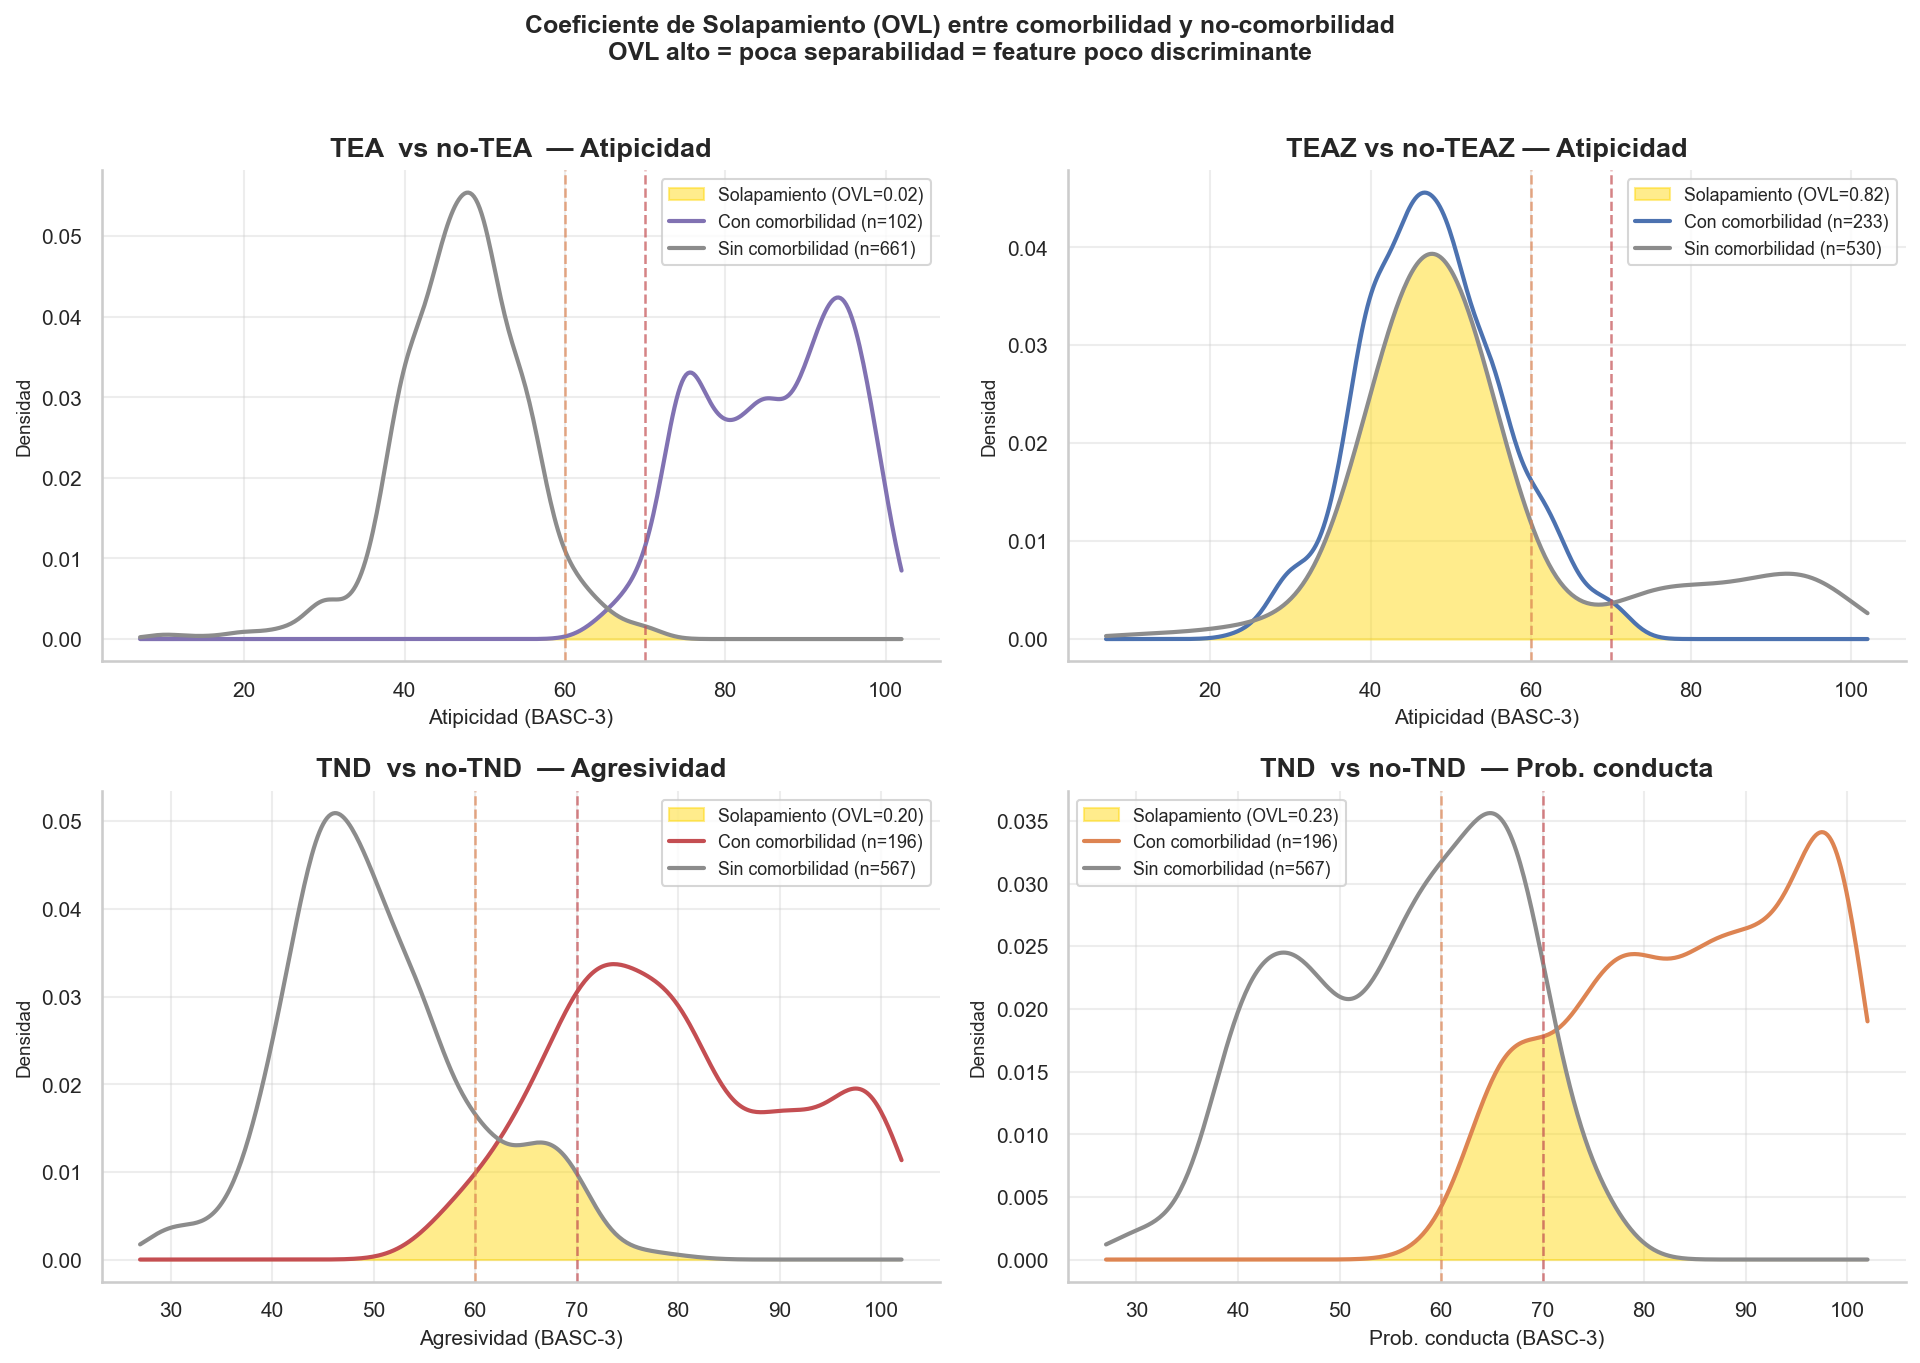


Resumen OVL:
Comparación                                   OVL    Interpretación
----------------------------------------------------------------------
  TEA  vs no-TEA  — Atipicidad                0.025  BAJO — buena separación
  TEAZ vs no-TEAZ — Atipicidad                0.816  ALTO — poca separabilidad
  TND  vs no-TND  — Agresividad               0.198  BAJO — buena separación
  TND  vs no-TND  — Prob. conducta            0.231  BAJO — buena separación


In [14]:
from scipy.stats import gaussian_kde

def overlap_coeff(a, b, n_points=500):
    lo = min(a.min(), b.min()) - 5
    hi = max(a.max(), b.max()) + 5
    xs = np.linspace(lo, hi, n_points)
    ka  = gaussian_kde(a, bw_method=0.3)(xs)
    kb  = gaussian_kde(b, bw_method=0.3)(xs)
    ovl = np.trapezoid(np.minimum(ka, kb), xs)
    return ovl

# Variables clave por comorbilidad
checks = [
    ('atipicidad_basc3',        'has_tea',  'TEA  vs no-TEA  — Atipicidad',    C_PURP),
    ('atipicidad_basc3',        'has_teaz', 'TEAZ vs no-TEAZ — Atipicidad',    C_BLUE),
    ('agresividad_basc3',       'has_tnd',  'TND  vs no-TND  — Agresividad',   C_RED),
    ('problemas_conducta_basc3','has_tnd',  'TND  vs no-TND  — Prob. conducta',C_ORG),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

tdah_df = df[df['is_tdah']].copy()

for ax, (var, flag, title, color) in zip(axes, checks):
    pos_v = tdah_df.loc[tdah_df[flag],  var].dropna().values.astype(float)
    neg_v = tdah_df.loc[~tdah_df[flag], var].dropna().values.astype(float)

    if len(pos_v) < 5:
        ax.text(0.5, 0.5, 'Insuf. casos', ha='center', transform=ax.transAxes)
        continue

    ovl = overlap_coeff(pos_v, neg_v)
    lo  = min(pos_v.min(), neg_v.min()) - 3
    hi  = max(pos_v.max(), neg_v.max()) + 3
    xs  = np.linspace(lo, hi, 400)
    ka  = gaussian_kde(pos_v, bw_method=0.3)(xs)
    kb  = gaussian_kde(neg_v, bw_method=0.3)(xs)

    ax.fill_between(xs, np.minimum(ka,kb), alpha=0.45, color='gold', label=f'Solapamiento (OVL={ovl:.2f})')
    ax.plot(xs, ka, color=color,  lw=2, label=f'Con comorbilidad (n={len(pos_v)})')
    ax.plot(xs, kb, color=C_GRAY, lw=2, label=f'Sin comorbilidad (n={len(neg_v)})')
    ax.axvline(60, color=C_ORG, lw=1.2, linestyle='--', alpha=0.7)
    ax.axvline(70, color=C_RED, lw=1.2, linestyle='--', alpha=0.7)
    ax.set_xlabel(FEATURE_LABELS.get(var, var), fontsize=10)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.set_title(title, pad=7)
    ax.legend(fontsize=8.5)

plt.suptitle('Coeficiente de Solapamiento (OVL) entre comorbilidad y no-comorbilidad\n'
             'OVL alto = poca separabilidad = feature poco discriminante', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nResumen OVL:")
print(f"{'Comparación':<45} OVL    Interpretación")
print("-"*70)
for (var, flag, title, color) in checks:
    pos_v = tdah_df.loc[tdah_df[flag],  var].dropna().values.astype(float)
    neg_v = tdah_df.loc[~tdah_df[flag], var].dropna().values.astype(float)
    if len(pos_v) < 5:
        print(f"  {title:<43} N/A    Insuf. casos")
        continue
    ovl = overlap_coeff(pos_v, neg_v)
    nivel = 'ALTO — poca separabilidad' if ovl > 0.70 else ('MODERADO' if ovl > 0.50 else 'BAJO — buena separación')
    print(f"  {title:<43} {ovl:.3f}  {nivel}")


📋 **Interpretación — Coeficiente de solapamiento**

El OVL complementa los tests de hipótesis: nos dice cuán mezcladas están las distribuciones en la práctica.

- **OVL > 0.70**: el 70%+ del área de distribución se comparte. Un clasificador basado en esa sola variable tendría mucho error — la separación existe pero hay gran confusión en los valores medios.
- **OVL 0.50–0.70**: separación moderada. La feature contribuye, pero no es suficiente sola.
- **OVL < 0.50**: las distribuciones tienen mayores regiones no solapadas. La feature discrimina bien.

En conjunto con los resultados del bloque 2, esto permite distinguir dos escenarios:
1. **Alta importancia + bajo OVL**: la feature realmente discrimina bien → relación directa con la comorbilidad
2. **Alta importancia + alto OVL**: la feature importa en el RF pero las distribuciones se mezclan → el modelo usa la feature en combinación con otras, no como separador limpio

---
## Bloque 5 — Síntesis

Las tres verificaciones anteriores (importancia binaria, comparación de distribuciones, OVL) convergen en un veredicto sobre la validez metodológica del modelo de 13 clases para cada tipo de comorbilidad.

In [15]:
# Tabla resumen de hallazgos
print("="*75)
print("SÍNTESIS — Análisis de solapamiento feature-diagnóstico por comorbilidad")
print("="*75)

for flag, label, vars_key in [
    ('has_tnd',  'TND',  ['agresividad_basc3','problemas_conducta_basc3']),
    ('has_teaz', 'TEAZ', ['atipicidad_basc3']),
    ('has_tea',  'TEA',  ['atipicidad_basc3']),
]:
    pos_v = tdah_df.loc[tdah_df[flag]]
    neg_v = tdah_df.loc[~tdah_df[flag]]
    n_pos = len(pos_v)

    print(f"\n  {label} (n={n_pos} casos):")
    for var in vars_key:
        if n_pos < 5:
            print(f"    {FEATURE_LABELS.get(var,var)}: insuf. casos")
            continue
        stat, pval = stats.mannwhitneyu(
            pos_v[var].dropna(), neg_v[var].dropna(), alternative='two-sided')
        n1, n2 = len(pos_v[var].dropna()), len(neg_v[var].dropna())
        r_rb   = 1 - 2*stat/(n1*n2)
        ovl_v  = overlap_coeff(
            pos_v[var].dropna().values.astype(float),
            neg_v[var].dropna().values.astype(float))
        print(f"    {FEATURE_LABELS.get(var,var):<35}"
              f" p={pval:.4f}  r={r_rb:+.3f}  OVL={ovl_v:.3f}")
print("\nNota: r = rank-biserial correlation (effect size); OVL = coef. solapamiento")
print("Umbral de decisión: p<0.05 + |r|>0.30 + OVL<0.70 = señal de solapamiento sustancial")


SÍNTESIS — Análisis de solapamiento feature-diagnóstico por comorbilidad

  TND (n=196 casos):
    Agresividad (BASC-3)                p=0.0000  r=-0.953  OVL=0.198
    Prob. conducta (BASC-3)             p=0.0000  r=-0.935  OVL=0.231

  TEAZ (n=233 casos):
    Atipicidad (BASC-3)                 p=0.0001  r=+0.177  OVL=0.816

  TEA (n=102 casos):
    Atipicidad (BASC-3)                 p=0.0000  r=-0.999  OVL=0.025

Nota: r = rank-biserial correlation (effect size); OVL = coef. solapamiento
Umbral de decisión: p<0.05 + |r|>0.30 + OVL<0.70 = señal de solapamiento sustancial


---
### Conclusión metodológica

Los resultados de este análisis determinan el riesgo de circularidad para el modelo de 13 clases:

**Si los efectos son grandes y el OVL es bajo** en las variables BASC-3 sospechosas:
- El modelo está usando features que son parcialmente proxies del criterio diagnóstico de la comorbilidad
- El rendimiento alto en esas clases refleja esta relación, no solo capacidad predictiva genuina
- **Recomendación**: documentarlo como limitación metodológica; validar externamente con otro equipo clínico

**Si los efectos son moderados o el OVL es alto**:
- Las features BASC-3 tienen señal pero con mucho solapamiento → el modelo integra múltiples variables débiles
- El riesgo de circularidad es menor → el modelo está haciendo un trabajo de integración no trivial
- **Recomendación**: el modelo es más robusto de lo esperado por la hipótesis de solapamiento

El notebook `ablation_study.ipynb` cuantifica el impacto en rendimiento cuando se eliminan las features sospechosas.

---
*Análisis de comorbilidades — Proyecto EDA-TDAH · Mayo 2026*